# Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from ydata_profiling import ProfileReport
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import scipy.stats as stats
from scipy.linalg import inv
from scipy.spatial import distance

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.multivariate.manova import MANOVA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.preprocessing import StandardScaler

import pingouin as pg

In [3]:
import statsmodels
print(statsmodels.__version__)

0.14.0


# Laod Data

In [4]:
filename = './Results/output02.csv'
df = pd.read_csv(filename, header=0, index_col=0)
df.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_cosine,Adj_euclidean,Adj_manhattan,Verb_cosine,Verb_euclidean,Verb_manhattan,Noun_cosine,Noun_euclidean,Noun_manhattan
MID,,,,,,,,,,,,,,,,
2,193.0,1,45,3,2,5,HighIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,137.0,1,36,4,2,2,LowIOS,NaN,NaN,NaN,0.933851,0.344139,1.932724,0.882830,0.469692,2.609289
7,293.0,1,54,1,2,5,HighIOS,0.489526,0.77925,4.465907,0.826740,0.433577,2.556113,0.035336,1.129285,6.480907
8,103.0,1,36,1,2,1,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,0.397660,1.097579,6.200497
11,160.0,1,56,1,2,2,LowIOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

rt                      0
self_sex                0
self_age                0
target_likedislike      0
target_sex              0
IOS_score               0
IOS_group               0
Adj_cosine            184
Adj_euclidean         184
Adj_manhattan         184
Verb_cosine           152
Verb_euclidean        152
Verb_manhattan        152
Noun_cosine           157
Noun_euclidean        157
Noun_manhattan        157
dtype: int64

# Create a Dataset for Cosine Similarity

In [6]:
# Remove some columns to create a new dataframe
df_cosine = df.drop(columns=['Adj_euclidean', 'Adj_manhattan',
                             'Verb_euclidean', 'Verb_manhattan',
                             'Noun_euclidean', 'Noun_manhattan'])
df_cosine.head()

,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_cosine,Verb_cosine,Noun_cosine
MID,,,,,,,,,,
2,193.0,1,45,3,2,5,HighIOS,NaN,NaN,NaN
5,137.0,1,36,4,2,2,LowIOS,NaN,0.933851,0.882830
7,293.0,1,54,1,2,5,HighIOS,0.489526,0.826740,0.035336
8,103.0,1,36,1,2,1,LowIOS,NaN,NaN,0.397660
11,160.0,1,56,1,2,2,LowIOS,NaN,NaN,NaN


# Data Profile

In [7]:
# The number of rows in the df_cosine
num_rows = len(df_cosine)
# The number of rows with missing value(s)
num_rows_nan = df_cosine.isnull().any(axis=1).sum()
# The percentage of rows with missing value(s)
percentage_rows_nan = num_rows_nan / num_rows * 100
# Print
print(f"Number of rows: {num_rows}")
print(f"Number of rows with missing value(s): {num_rows_nan}")
print(f"Percentage of missing data: {percentage_rows_nan}")

Number of rows: 403
Number of rows with missing value(s): 222
Percentage of missing data: 55.08684863523573


In [8]:
# Drop rows with missing value(s)
df_cosine = df_cosine.dropna()
print(len(df_cosine))
df_cosine.head()

181


,rt,self_sex,self_age,target_likedislike,target_sex,IOS_score,IOS_group,Adj_cosine,Verb_cosine,Noun_cosine
MID,,,,,,,,,,
7,293.0,1,54,1,2,5,HighIOS,0.489526,0.826740,0.035336
47,286.0,2,49,1,2,1,LowIOS,0.343798,0.767628,0.868594
64,454.0,2,47,2,1,3,LowIOS,0.580847,0.837091,0.656584
66,457.0,2,55,2,1,5,HighIOS,0.557176,0.751485,0.622296
78,175.0,2,42,4,1,2,LowIOS,0.720062,0.695203,0.480041


target_likedislike_binary  IOS_score
dislike                    1            19
                           2            18
                           3            18
                           6            14
                           5            11
                           7             6
like                       7            21
                           6            18
                           2            17
                           1            14
                           5            13
                           3            12
Name: count, dtype: int64


/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

<Axes: xlabel='IOS_score', ylabel='count'>

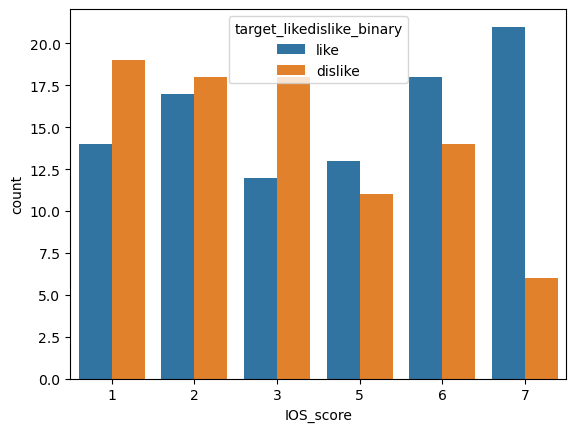

In [9]:
# Add a new column where the target_likedislike is converted to a binary variable (0: dislike, 1: like)
df_cosine.loc[:, 'target_likedislike_binary'] = np.where(df_cosine['target_likedislike'] < 4, 'like', 'dislike')
# The number of occurrences of each value in the IOS_group column with respect to the target_likedislike_binary
print(df_cosine.groupby('target_likedislike_binary')['IOS_score'].value_counts())
# The count plot of the IOS_group column with respect to the target_likedislike_binary
sns.countplot(x='IOS_score', hue='target_likedislike_binary', data=df_cosine) 

In [10]:
# The descriptive statistics of self_age with respect to the IOS_group and self_sex
df_cosine.groupby(['IOS_group', 'self_sex'])['self_age'].describe()

count       mean       std   min    25%   50%   75%   max
IOS_group self_sex                                                           
HighIOS   1          45.0  49.022222  8.817567  24.0  44.00  52.0  56.0  59.0
          2          38.0  47.078947  8.234343  27.0  43.25  48.0  54.0  58.0
LowIOS    1          49.0  50.489796  7.243165  33.0  46.00  52.0  57.0  59.0
          2          49.0  46.755102  9.148157  24.0  41.00  49.0  54.0  59.0

           count         mean           std    min     25%    50%     75%  \
IOS_group                                                                   
HighIOS     83.0  2298.566265  10644.594135  132.0  266.00  434.0  714.50   
LowIOS      98.0   855.387755   2277.461906  106.0  309.75  451.5  752.75   

               max  
IOS_group           
HighIOS    89172.0  
LowIOS     22147.0  


/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


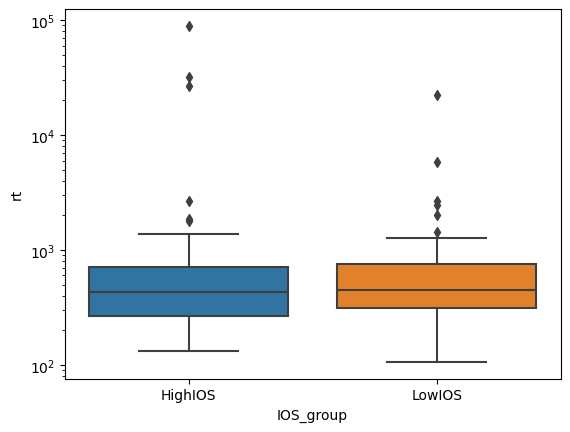

In [11]:
# The descriptive statistics of rt with respect to IOS_group
print(df_cosine.groupby('IOS_group')['rt'].describe())
# The boxplot of rt with respect to IOS_group
sns.boxplot(x='IOS_group', y='rt', data=df_cosine, order=['HighIOS', 'LowIOS'])
plt.yscale('log')
plt.show()

In [12]:
# Add a new column for whether the self_sex differs from the target_sex
df_cosine.loc[:, 'diff_sex'] = df_cosine['self_sex'] != df_cosine['target_sex']
# The count of occurrence of each value in the diff_sex with the respect of the IOS_group
df_cosine.groupby('IOS_group')['diff_sex'].value_counts()

IOS_group  diff_sex
HighIOS    True        63
           False       20
LowIOS     True        62
           False       36
Name: count, dtype: int64

In [13]:
# The descriptive statistics of the Adj_cosine column with respect to the IOS_group
df_cosine.groupby('IOS_group')['Adj_cosine'].describe()

,count,mean,std,min,25%,50%,75%,max
IOS_group,,,,,,,,
HighIOS,83.0,0.629446,0.206112,0.076658,0.489070,0.684356,0.795388,0.939759
LowIOS,98.0,0.638761,0.211402,0.076291,0.507813,0.663839,0.790882,1.000000


In [14]:
# The descriptive statistics of the Verb_cosine column with respect to the IOS_group
df_cosine.groupby('IOS_group')['Verb_cosine'].describe()

,count,mean,std,min,25%,50%,75%,max
IOS_group,,,,,,,,
HighIOS,83.0,0.734093,0.179685,0.146441,0.658899,0.770900,0.867098,1.000000
LowIOS,98.0,0.683858,0.212157,-0.017176,0.592730,0.734477,0.835116,0.962621


In [15]:
# The descriptive statistics of the Noun_cosine column with respect to the IOS_group
df_cosine.groupby('IOS_group')['Noun_cosine'].describe()

,count,mean,std,min,25%,50%,75%,max
IOS_group,,,,,,,,
HighIOS,83.0,0.667836,0.206059,0.035336,0.571712,0.707679,0.827802,1.000000
LowIOS,98.0,0.642174,0.196058,0.032985,0.560599,0.687272,0.787272,0.933012


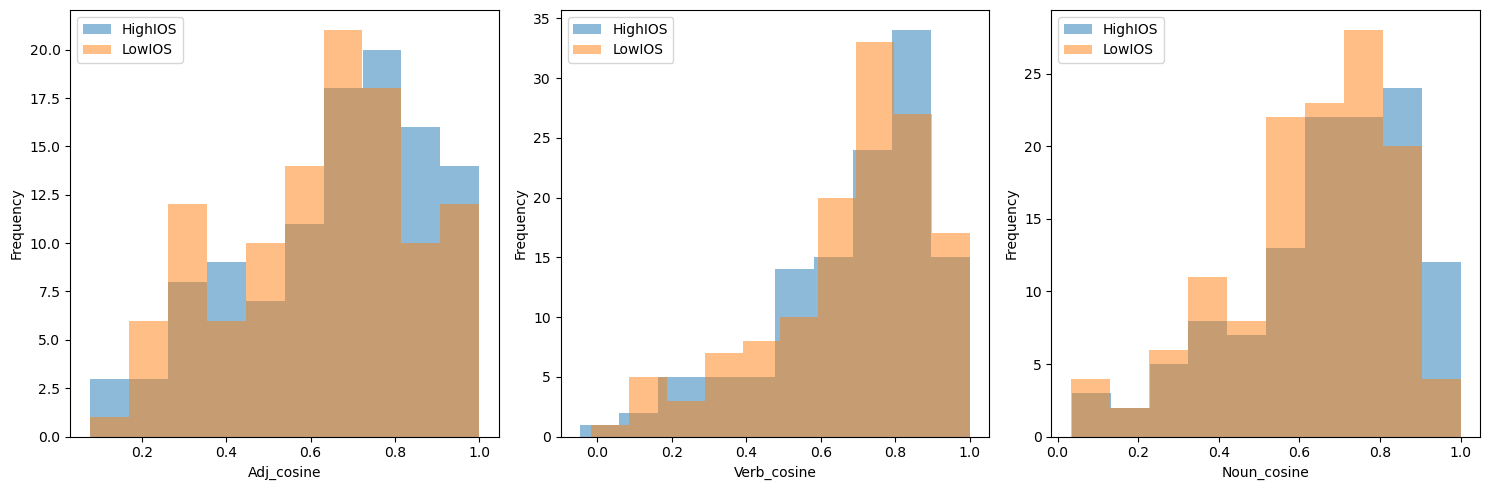

In [16]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the histogram for Adj_cosine
axes[0].hist(df['Adj_cosine'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
axes[0].hist(df['Adj_cosine'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
axes[0].set_xlabel('Adj_cosine')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Plot the histogram for Verb_cosine
axes[1].hist(df['Verb_cosine'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
axes[1].hist(df['Verb_cosine'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
axes[1].set_xlabel('Verb_cosine')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot the histogram for Noun_cosine
axes[2].hist(df['Noun_cosine'][df['IOS_group'] == 'HighIOS'], bins=10, alpha=0.5, label='HighIOS')
axes[2].hist(df['Noun_cosine'][df['IOS_group'] == 'LowIOS'], bins=10, alpha=0.5, label='LowIOS')
axes[2].set_xlabel('Noun_cosine')
axes[2].set_ylabel('Frequency')
axes[2].legend()

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

# Assumption Check

## Visualizing Data Distribution

/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

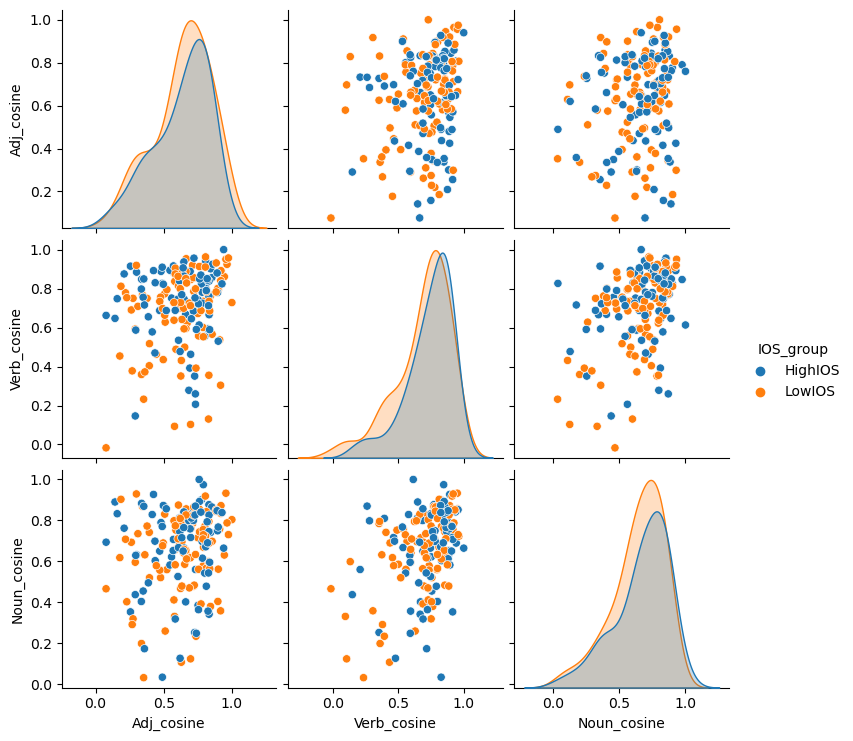

In [17]:
# Assume df_cosine is your DataFrame and it has columns 'Adj_cosine', 'Verb_cosine', 'Noun_cosine', and 'IOS_group'
sns.pairplot(df_cosine, vars=['Adj_cosine', 'Verb_cosine', 'Noun_cosine'], hue='IOS_group')
plt.show()

## Multivariate Normality

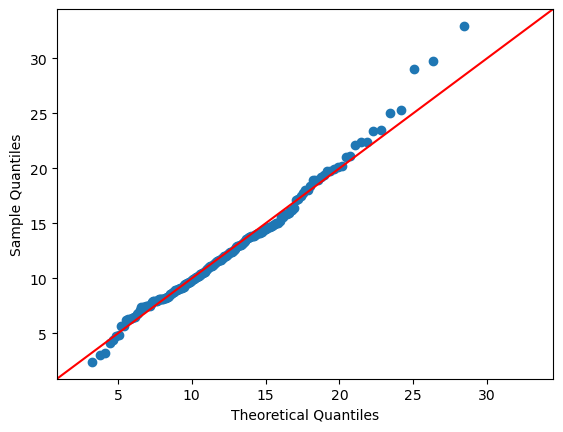

In [18]:
# Create a Q-Q plot for multivariate normality by using Mahalanobis distance,
# which measures distance between a point and a distribution
 
# Assume df_cosine is your DataFrame and it has columns 'Adj_cosine', 'Verb_cosine', and 'Noun_cosine'
X = df_cosine[['Adj_cosine', 'Verb_cosine', 'Noun_cosine']].values

# Standardize the data
X_std = StandardScaler().fit_transform(X)

# Calculate the Mahalanobis distance
mahalanobis = np.sqrt((X_std**2).sum(axis=1))

# # Calculate the mean of the data
# mean = np.mean(X, axis=0)
# 
# # Calculate the covariance matrix
# cov = np.cov(X, rowvar=False)
# 
# # Calculate the inverse of the covariance matrix
# inv_cov = inv(cov)
# 
# # Calculate the Mahalanobis distance
# mahalanobis = np.array([distance.mahalanobis(x, mean, inv_cov) for x in X])

# Create Q-Q plot
sm.qqplot(mahalanobis, stats.chi2, distargs=(3,), line='45', fit=True) 
plt.show()

In [19]:
# The Shapiro-Wilk test to tell if a random sample comes from a normal distribution.
# The null hypothesis of the test is that the data are normally distributed.
# 
# The Shapiro-Wilk test is typically used to test the normality of univariate data.
# For multivariate data, you might want to consider using a multivariate normality test, such as the Henze-Zirkler's multivariate normality test provided by the `pingouin` package.
# However, if you still want to apply the Shapiro-Wilk test to each variable in your multivariate data, you can do so by iterating over the columns of your DataFrame. Here's how you can do it:

# Assume df_cosine is your DataFrame and it has columns 'Adj_cosine', 'Verb_cosine', and 'Noun_cosine'
variables = ['Adj_cosine', 'Verb_cosine', 'Noun_cosine']

for var in variables:
    shapiro_test = stats.shapiro(df_cosine[var])
    print(f"Shapiro test for {var}: statistic={shapiro_test.statistic}, p-value={shapiro_test.pvalue}")

Shapiro test for Adj_cosine: statistic=0.9525640606880188, p-value=9.29785892367363e-06
Shapiro test for Verb_cosine: statistic=0.8954517245292664, p-value=5.638504663174615e-10
Shapiro test for Noun_cosine: statistic=0.9309797883033752, p-value=1.376540836872664e-07


In [20]:
# The Henze-Zirkler's multivariate normality test

# Assume df_cosine is your DataFrame and it has columns 'Adj_cosine', 'Verb_cosine', 'Noun_cosine'
X = df_cosine[['Adj_cosine', 'Verb_cosine', 'Noun_cosine']]

# Perform multivariate normality test
result = pg.multivariate_normality(X)
print(result)

HZResults(hz=3.5444265103606676, pval=3.108207861526467e-17, normal=False)


## Homogeneity of covariance matrices

In [21]:
# The Box's M test to examine the homogeneity of covariance matrices across groups.
# The null hypothesis of the test is that the covariance matrices are equal across groups.

# Perform Box's M test
result = pg.multivariate.box_m(data=df_cosine, dvs=['Adj_cosine', 'Verb_cosine', 'Noun_cosine'], group='IOS_group')
print(result)

         Chi2   df     pval  equal_cov
box  9.572037  6.0  0.14387       True


## Indepency of observations

In [22]:
# Replace 'HighIOS' with 1 and 'LowIOS' with 0 in the 'IOS_group' column
df_cosine['IOS_group'] = df_cosine['IOS_group'].replace({'HighIOS': 1, 'LowIOS': 0}).astype(int)

In [23]:
# ADJ_COSINE
md = smf.mixedlm("Adj_cosine ~ C(1|IOS_group)", df_cosine, groups=df_cosine["IOS_group"])
mdf = md.fit(reml=True)
print(mdf.summary())
print("Residual Var: ", mdf.scale)
print("Group Var: ", mdf.cov_re.iloc[0, 0])
print('rho_adj:', mdf.cov_re.iloc[0, 0] / (mdf.cov_re.iloc[0, 0] + mdf.scale))

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Adj_cosine
No. Observations: 181     Method:             REML      
No. Groups:       2       Scale:              0.0435    
Min. group size:  83      Log-Likelihood:     24.2284   
Max. group size:  98      Converged:          Yes       
Mean group size:  90.5                                  
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  0.634     0.015  40.979  0.000   0.604   0.665
Group Var  0.000                                         

Residual Var:  0.04345790620128074
Group Var:  6.728855523989928e-12
rho_adj: 1.548361647195454e-10


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [24]:
# Verb_cosine
md = smf.mixedlm("Verb_cosine ~ C(1|IOS_group)", df_cosine, groups=df_cosine["IOS_group"])
mdf = md.fit(reml=True)
print(mdf.summary())
print("Residual Var: ", mdf.scale)
print("Group Var: ", mdf.cov_re.iloc[0, 0])
print('rho_verb:', mdf.cov_re.iloc[0, 0] / (mdf.cov_re.iloc[0, 0] + mdf.scale))

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Verb_cosine
No. Observations: 181     Method:             REML       
No. Groups:       2       Scale:              0.0392     
Min. group size:  83      Log-Likelihood:     33.0194    
Max. group size:  98      Converged:          Yes        
Mean group size:  90.5                                   
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.708     0.025  28.185  0.000   0.659   0.758
Group Var   0.001     0.009                               

Residual Var:  0.03918176392772131
Group Var:  0.0008258982672264948
rho_verb: 0.020643502317183374


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [25]:
# Noun_cosine
md = smf.mixedlm("Noun_cosine ~ C(1|IOS_group)", df_cosine, groups=df_cosine["IOS_group"])
mdf = md.fit(reml=True)
print(mdf.summary())
print("Residual Var: ", mdf.scale)
print("Group Var: ", mdf.cov_re.iloc[0, 0])
print('rho_noun:', mdf.cov_re.iloc[0, 0] / (mdf.cov_re.iloc[0, 0] + mdf.scale))

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Noun_cosine
No. Observations: 181     Method:             REML       
No. Groups:       2       Scale:              0.0402     
Min. group size:  83      Log-Likelihood:     31.1931    
Max. group size:  98      Converged:          Yes        
Mean group size:  90.5                                   
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.654     0.015  43.399  0.000   0.624   0.683
Group Var   0.000     0.005                               

Residual Var:  0.040221762375386126
Group Var:  5.957721375122009e-11
rho_noun: 1.4812183789199588e-09


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Pairplot & Correlation Matrix

/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

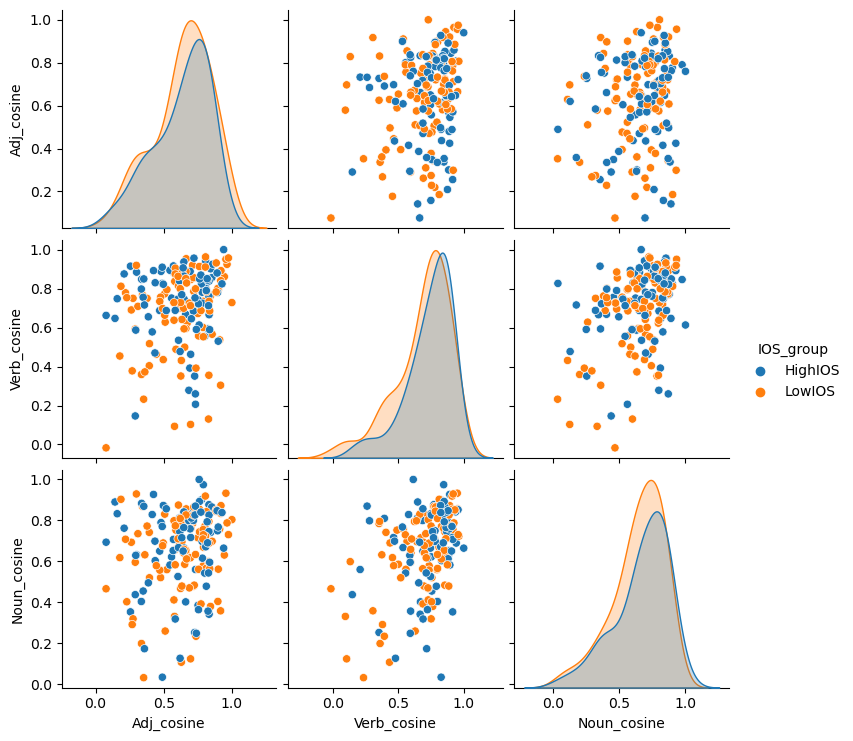

In [26]:
# Replace 1 with 'HighIOS' and 0 with 'LowIOS' in the 'IOS_group' column
df_cosine['IOS_group'] = df_cosine['IOS_group'].replace({1: 'HighIOS', 0: 'LowIOS'})
# Piarplot for Adj_cosine, Verb_cosine, and Noun_cosine hue='IOS_group'
sns.pairplot(df_cosine, vars=['Adj_cosine', 'Verb_cosine', 'Noun_cosine'], hue='IOS_group')

In [27]:
# Correlation matrix for Adj_cosine, Verb_cosine, and Noun_cosine of HighIOS and LowIOS
df_cosine.groupby('IOS_group')[['Adj_cosine', 'Verb_cosine', 'Noun_cosine']].corr()

Adj_cosine  Verb_cosine  Noun_cosine
IOS_group                                                  
HighIOS   Adj_cosine     1.000000     0.046441     0.110288
          Verb_cosine    0.046441     1.000000     0.242417
          Noun_cosine    0.110288     0.242417     1.000000
LowIOS    Adj_cosine     1.000000     0.306337     0.207166
          Verb_cosine    0.306337     1.000000     0.526887
          Noun_cosine    0.207166     0.526887     1.000000

In [28]:
# save df_cosine to a csv file
df_cosine.to_csv('./Experiments/df_cosine.csv', index=False)

# MANOVA

In [29]:
# MANOVA for Adj_cosine, Verb_cosine, Noun_cosine
maov_cosine = MANOVA.from_formula('Adj_cosine + Verb_cosine + Noun_cosine ~ IOS_group', data=df_cosine[['IOS_group', 'Adj_cosine', 'Verb_cosine', 'Noun_cosine']])
print(maov_cosine.mv_test())

                   Multivariate linear model
                                                               
---------------------------------------------------------------
       Intercept         Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0879 3.0000 177.0000 612.1678 0.0000
         Pillai's trace  0.9121 3.0000 177.0000 612.1678 0.0000
 Hotelling-Lawley trace 10.3757 3.0000 177.0000 612.1678 0.0000
    Roy's greatest root 10.3757 3.0000 177.0000 612.1678 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
         IOS_group        Value  Num DF  Den DF  F Value Pr > F
---------------------------------------------------------------
            Wilks' lambda 0.9815 3.0000 177.0000  1.1139 0.3449
           Pillai's trace 0.0185 3.0000 177.0000  1.1139 0.

# --------Storage-------

## Euclidean Similarity

In [ ]:
df_euclidean = df[['IOS_group', 'Adj_euclidean', 'Verb_euclidean', 'Noun_euclidean']]
df_euclidean.head()

In [ ]:
df_euclidean.groupby('IOS_group').count()

In [ ]:
df_euclidean.groupby('IOS_group').agg([np.mean, np.std]).T

In [ ]:
# MANOVA for Adj_euclidean, Verb_euclidean, Noun_euclidean
maov_euclidean = MANOVA.from_formula('Adj_euclidean + Verb_euclidean + Noun_euclidean ~ IOS_group', data=df_euclidean)
print(maov_euclidean.mv_test())

In [ ]:
# Create a line plot of Adj_euclidean, Verb_euclidean, Noun_euclidean
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_euclidean, x="IOS_group", y="Adj_euclidean", label="Adj_euclidean")
sns.lineplot(data=df_euclidean, x="IOS_group", y="Verb_euclidean", label="Verb_euclidean")
sns.lineplot(data=df_euclidean, x="IOS_group", y="Noun_euclidean", label="Noun_euclidean")
ax.set_ylim(0, 1)
plt.show()

## Manhatan Similarity

In [ ]:
df_manhattan = df[['IOS_group', 'Adj_manhattan', 'Verb_manhattan', 'Noun_manhattan']]
df_manhattan.head()

In [ ]:
df_manhattan.groupby('IOS_group').count()

In [ ]:
df_manhattan.groupby('IOS_group').agg([np.mean, np.std]).T

In [ ]:
# MANOVA for Adj_manhattan, Verb_manhattan, Noun_manhattan
maov_manhattan = MANOVA.from_formula('Adj_manhattan + Verb_manhattan + Noun_manhattan ~ IOS_group', data=df_manhattan)
print(maov_manhattan.mv_test())

In [ ]:
# Create a line plot of Adj_manhattan, Verb_manhattan, Noun_manhattan
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_manhattan, x="IOS_group", y="Adj_manhattan", label="Adj_manhattan")
sns.lineplot(data=df_manhattan, x="IOS_group", y="Verb_manhattan", label="Verb_manhattan")
sns.lineplot(data=df_manhattan, x="IOS_group", y="Noun_manhattan", label="Noun_manhattan")
ax.set_ylim(0, 5)
plt.show()

# Exploratory Analyses

## 01: a one-tailed independent two-sample t-test
The author had planned:
- sample size: 51 for each group
- alpha: 0.05
- effect size: 0.5
- power: 0.8

In [ ]:
groupH = df[df['IOS_group']=='HighIOS']
groupL = df[df['IOS_group']=='LowIOS']

In [ ]:
len(groupH)

In [ ]:
len(groupL)

### Overlapping Magnitude

In [ ]:
stats.ttest_ind(groupH['Overlap_score'], groupL['Overlap_score'], equal_var=False, alternative='greater') # perform Welch's t-test without assuming equal population variance.

In [ ]:
stats.ttest_ind(groupH['Overlap_score'], groupL['Overlap_score'], equal_var=False, alternative='less') # perform Welch's t-test without assuming equal population variance.

### Euclidean Distance

In [ ]:
stats.ttest_ind(groupH['euclidean_distance'], groupL['euclidean_distance'], equal_var=False, alternative='less')

In [ ]:
stats.ttest_ind(groupH['euclidean_distance'], groupL['euclidean_distance'], equal_var=False, alternative='greater')

### Manhattan Distance

In [ ]:
stats.ttest_ind(groupH['manhattan_distance'], groupL['manhattan_distance'], equal_var=False, alternative='less')

In [ ]:
stats.ttest_ind(groupH['manhattan_distance'], groupL['manhattan_distance'], equal_var=False, alternative='greater')

### Cosine Similarity

In [ ]:
stats.ttest_ind(groupH['cosine_similarity'], groupL['cosine_similarity'], equal_var=False, alternative='greater')

In [ ]:
stats.ttest_ind(groupH['cosine_similarity'], groupL['cosine_similarity'], equal_var=False, alternative='less')

### Post hoc Power Analysis

In [ ]:
print('Num. of group H: ' + str(len(groupH)))
print('Num. of group L: ' + str(len(groupL)))

In [ ]:
def cohens_d(x1, x2):
    n1 = len(x1)
    n2 = len(x2)
    x1_mean = x1.mean()
    x2_mean = x2.mean()
    s1 = x1.std()
    s2 = x2.std()
    s = np.sqrt((n1*np.square(s1) + n2*np.square(s2)) / (n1 + n2))
    d = np.abs(x1_mean - x2_mean) / s
    return d

In [ ]:
euclidean_d = cohens_d(groupH['euclidean_distance'], groupL['euclidean_distance'])
print('Cohen''s d (Euclidean distance): {:.4f}'.format(euclidean_d))
manhattan_d = cohens_d(groupH['manhattan_distance'], groupL['manhattan_distance'])
print('Cohen''s d (Manhattan distance): {:.4f}'.format(manhattan_d))
cosine_d = cohens_d(groupH['cosine_similarity'], groupL['cosine_similarity'])
print('Cohen''s d (Cosine similarity): {:.4f}'.format(cosine_d))

In [ ]:
# Compute post hoc power powered by G*Power
print('Post hoc power (Euclidean distance): {:.4f}'.format(0.2791))
print('Post hoc power (Manhattan distance): {:.4f}'.format(0.2417))
print('Post hoc power (Cosine similarity): {:.4f}'.format(0.4981))

## 02: Spearman's rank correlation coefficient between the IOS scores and the overlapping scores
The author had planned:
- sample size: 119, including participants who rated on the IOS scale as 4
- alpha: 0.05
- effect size: 0.3
- power: 0.93
- two-tailed


### Overlapping score

In [ ]:
df.head(1)

In [ ]:
iosscores = df['IOS_score']
overlapscores = df['Overlap_score']

In [ ]:
res = stats.spearmanr(iosscores, overlapscores)
res

### Euclidean Dsitance

In [ ]:
euclidean_distance = df['euclidean_distance']
res = stats.spearmanr(iosscores, euclidean_distance)
res

### Manhattan Distance

In [ ]:
manhattan_distance = df['manhattan_distance']
res = stats.spearmanr(iosscores, manhattan_distance)
res

### Cosine Similarity

In [ ]:
cosine_similarity = df['cosine_similarity']
res = stats.spearmanr(iosscores, cosine_similarity)
res

### Post hoc Power Analysis

In [ ]:
print('Num. of Sumple of the IOS socre: ' + str(len(iosscores)))
print('Num. of Sumple of the Overlapping socre: ' + str(len(overlapscores)))

Achieved power: 0.23 (H1: rho1 = 0.127)